In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
from scipy.spatial import distance
import os

In [2]:
# Define pockets
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
pockets = sorted(os.listdir(PATH_TO_DOCKING_RESULTS))

# Load labels
root = '../../../Documents/mtb-targeted-protein-degradation/scripts'
PATH_TO_PROBS = os.path.join(root, "..", "processed", "unidock_docking", "inferences_top100k")
labels = np.array(pickle.load(open(os.path.join(PATH_TO_PROBS, "success_mols.pkl"), "rb")))

# Load probabilities
pocket_to_all_probs = {}
for c, pocket in tqdm(enumerate(pockets)):
    probs = np.load(os.path.join(PATH_TO_PROBS, f"{pocket}_bin_01.npz"))["arr_0"]
    pocket_to_all_probs[pocket] = probs

276it [00:27, 10.08it/s]


In [3]:
# Prepare matrix
M = np.column_stack([pocket_to_all_probs[p] for p in pockets])
del pocket_to_all_probs

# Calculate means
means = np.mean(M, axis=1, keepdims=True)

# Calculate stds
stds = np.std(M, axis=1, keepdims=True)

# Calculate Z-score
Z = (M - means) / stds

In [4]:
TOPs = [100, 1000, 10000, 100000]
l = len(pockets)
HIT_OVERLAP = {i: {} for i in TOPs}

pocket_to_inds = {}
# For each pocket
for c, pocket in tqdm(enumerate(pockets)):
    # Get indices that sort z-scored probs - limited to MAX(TOPs)
    ind = np.argsort(Z[:, c])[::-1][:max(TOPs)]
    pocket_to_inds[pocket] = np.array(ind, dtype='int32')

276it [03:54,  1.18it/s]


In [5]:
# For each pocket1
for c1, pocket1 in tqdm(enumerate(pockets)):
    # For each pocket2
    for c2, pocket2 in enumerate(pockets[c1:]):
        # For each hit set
        for c3, TOP in enumerate(TOPs):
            h1 = pocket_to_inds[pocket1][:TOP]
            h2 = pocket_to_inds[pocket2][:TOP]
            HIT_OVERLAP[TOP][(pocket1, pocket2)] = np.intersect1d(h1, h2).size
            HIT_OVERLAP[TOP][(pocket2, pocket1)] = HIT_OVERLAP[TOP][(pocket1, pocket2)]

276it [01:29,  3.09it/s]


In [6]:
# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))
pocket_to_coords = {}

for file, pocket_numb, coord in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'], pocket_detection_data['Pocket centroid coordinate (x y z)']):
    
    # Prepare labels
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)

    # Create mappings
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

In [9]:
diff_protein = {i: {} for i in TOPs}
same_protein = {i: {} for i in TOPs}
same_pocket = {i: {} for i in TOPs}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            for TOP in TOPs:
                diff_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                for TOP in TOPs:
                    same_pocket[TOP][pair] = HIT_OVERLAP[TOP][pair]

            # If the pocket is not the same
            else:
                for TOP in TOPs:
                    same_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

276it [00:00, 3852.94it/s]


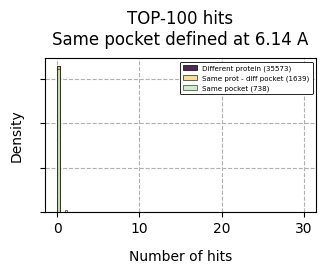

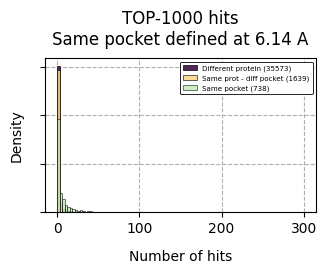

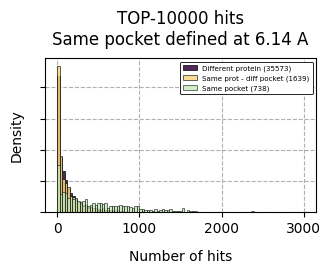

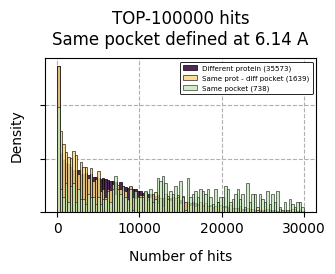

In [15]:
for TOP in TOPs:

    plt.figure(figsize=(3.5, 2))

    bins = np.linspace(0, TOP*0.3, 100)
    plt.hist(np.array(list(diff_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein[TOP])})', zorder=2, density=True)
    plt.hist(np.array(list(same_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein[TOP])})', zorder=2, density=True, alpha=0.85)
    plt.hist(np.array(list(same_pocket[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket[TOP])})', zorder=2, density=True, alpha=0.75)

    title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
    plt.title(title, pad=10)
    plt.gca().set_yticklabels([])
    plt.xlabel("Number of hits", labelpad=10)
    plt.ylabel("Density", labelpad=8)
    plt.grid(linestyle='--', zorder=-2)
    l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
    l.get_frame().set_linewidth(0.6)
    plt.show()